In [19]:


inter_interest = ['zorro','clavicle','G2N-1','rattle','usnea','FMin','phantom','bract','FDG','roundup']

import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
from scipy.stats import dunnett
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *
from fitting import sigmoid

matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


from make_network import sez
sez_ids = np.concatenate(list(sez.values()))
sez_id2g = {f:g for g,fid in sez.items() for f in fid}


In [40]:
exp_df = pd.read_excel('data/optogenetics_hit.xlsx',sheet_name='- geosmin')
df = pd.read_excel('data/Optogenetics_simualtion_sweet.xlsx',header=1) 
df = df[
    df['exp_name'] != 'MN9 freq per type [Hz]'
].copy()

df = df.set_index('exp_name')


fitting_result_path = Path(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting')
params_opt_tarsal = pickle.load(open(fitting_result_path/'fitting_result/tarsal/result_av1a1_170.pkl','rb'))
params_opt_labial = pickle.load(open(fitting_result_path/'fitting_result/labial/result_av1a1_170.pkl','rb'))
V_l1l2,K_l1l2,n_l1l2,V_l3,K_l3,n_l3,k_act_L,r0_L,h_L = params_opt_labial.x
V_at,K_at,n_at,V_tp,K_tp,n_tp,k_act_T,r0_T,h_T = params_opt_tarsal.x
popt_tarsal = [k_act_T,r0_T,h_T]
popt_labial = [k_act_L,r0_L,h_L]



df_labial = sigmoid(df,*popt_labial) - sigmoid(0,*popt_labial)
df_tarsal = sigmoid(df,*popt_tarsal) - sigmoid(0,*popt_tarsal)

In [41]:
import networkx as nx
tarsal_union = nx.read_gexf(REPO_ROOT/'figure5/figure5Q,R/result_network/tarsal_union.gexf')
labial_union = nx.read_gexf(REPO_ROOT/'figure5/figure5Q,R/result_network/labial_union.gexf')

tarsal_nodes = list(tarsal_union.nodes)
tarsal_nodes[tarsal_nodes.index('TH_VUM')] = 'TH-VUM'
labial_nodes = list(labial_union.nodes)


cell2color = {}
for g in df_labial.index:
    if (g in tarsal_nodes) & (g in labial_nodes):
        cell2color[g] = '#00ffff'
    elif (g in labial_nodes):
        cell2color[g] = "#00AA66"
    elif (g in tarsal_nodes):
        cell2color[g] = "#0066FF"
    else:
        cell2color[g] = '#777777'

In [42]:
error_by_freq = {}

freq = 60 
ff = f'{freq}Hz'

exp_mean = exp_df.mean()
exp_mean.loc['sink and sync SS'] = 0

name = [x.split(' SS')[0] for x in exp_mean.index]
name = ['FMIn' if x == 'FMin' else x for x in name]

data_df_all = pd.DataFrame(index=name)
data_df_all['exp'] = exp_mean.values
data_df_all['simul'] = df_labial.reindex(name)[ff].values

data_df_all = data_df_all.dropna()



findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

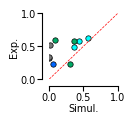

In [43]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

import distinctipy
fontsize=7

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.22



fig,ax = plt.subplots(1,1,figsize=(.9,.9),constrained_layout=False)
for i,c in enumerate(data_df_all.index.values):
    x = data_df_all.iloc[i]['simul']
    y = data_df_all.iloc[i]['exp']
    ax.scatter(x,y,s=15,c=cell2color[c],label=c,edgecolors='black',lw=0.5)
    
    
ax.plot(list(np.arange(0,1.2,.1)),list(np.arange(0,1.2,.1)),color='r',linestyle='dashed',lw=0.5)



ax.spines[['top','right']].set_visible(False)
ax.set_xticks(np.round(np.arange(0,1.1,.5),2))
ax.set_yticks(np.round(np.arange(0,1.1,.5),2))
ax.set_xticklabels(np.round(np.arange(0,1.1,.5),2),fontsize=fontsize)
ax.set_yticklabels(np.round(np.arange(0,1.1,.5),2),fontsize=fontsize)
ax.set_ylabel('Exp. ',fontsize=fontsize)
ax.set_xlabel('Simul.',fontsize=fontsize)
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.tick_params(pad=1)
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5


fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)
# plt.savefig('activation_compare_labellar_activation_func.svg')